# Підготовка даних (агрегація даних DNS-трафіку до рівня домену)

Кожен рядок = один домен * часове вікно (тривалість захоплення трафіку)  

### Вхідні дані:
| Файл | Роль |
|---|---|
| `dns_botnet54.log` | Навчальні (TRAIN) дані (CTU-Malware-Capture-Botnet-54) |
| `dns_botnet46.log` | Тестові (TEST) дані (CTU-Malware-Capture-Botnet-46) |
| `asn.csv` | Зіставлення IP-адрес до номерів AS та кодів країн |

In [1]:
# відлік часу для розрахунку часу виконання ноутбуку
import time
_notebook_start = time.perf_counter()

import pandas as pd # обробка табличних даних
import numpy as np # векторні обчислення та операції з масивами
import ipaddress # перетворення і валідація IPv4-адрес
from pathlib import Path # робота зі шляхами до файлів

from scipy.stats import entropy as scipy_entropy # ентропія Шеннона для розподілу TTL
from sklearn.preprocessing import StandardScaler # z-score нормалізація числових ознак

import matplotlib.pyplot as plt # відображення графіків
%matplotlib inline 
# вбудоване відображення графіків

import warnings
warnings.filterwarnings('ignore') # ігнорування помилок для чистого виводу результатів обчислень у комірках

In [2]:
# для навчальних даних (CTU-Malware-Capture-Botnet-54)
DNS_LOG_PATH = Path('dns_botnet54.log') # DNS-лог Zeek із трафіку Botnet-54
OUTPUT_CSV = Path('ff_agg_botnet54.csv') # агрегований набір даних на виході

# для тестових даних (CTU-Malware-Capture-Botnet-46)
#DNS_LOG_PATH = Path('dns_botnet46.log')
#OUTPUT_CSV   = Path('ff_agg_botnet46.csv')

ASN_CSV = Path('asn.csv') # відповідність IP-діапазонів до номерів AS і країн

# TTL нижче 300 секунд вважається аномально малим
LOW_TTL_THR = 300

# IP-адреса зараженого хоста (генерує fast-flux-запити): label = 1
BOTNET_IPS = {'147.32.84.165'}

# IP-адреси легітимних хостів у тій самій мережі: label = 0
NORMAL_IPS = {'147.32.84.170', '147.32.84.134', '147.32.84.164', '147.32.87.36',  '147.32.80.9',   '147.32.87.11'}

print(f'Вхід: {DNS_LOG_PATH}')
print(f'Вихід: {OUTPUT_CSV}')

Вхід: dns_botnet54.log
Вихід: ff_agg_botnet54.csv


## 1. Завантаження файлу asn.csv із відповідністю IP-діапазонів до ASN та кодів країн

In [3]:
# asn.csv містить записи виду range_start, range_end, AS_number, country_code, AS_description
asn = pd.read_csv(
    ASN_CSV,
    names=['range_start','range_end','AS_number','country_code','AS_description'],
    header=0, dtype=str, skipinitialspace=True, engine='python'
)

# видалення зайвих пробілів у назвах стовпців і значеннях клітинок
asn.columns = asn.columns.str.strip()
asn = asn.apply(lambda x: x.str.strip() if x.dtype == 'object' else x)

# залишаємо рядки, у яких обидві межі діапазону є коректними IPv4-адресами
asn = asn[asn['range_start'].str.match(r'^\d+\.\d+\.\d+\.\d+$', na=False)]
asn = asn[asn['range_end'].str.match(r'^\d+\.\d+\.\d+\.\d+$', na=False)]

# перетворюємо тккстові IP-адреси у 32-бітні цілі числа для подальшого бінарного пошуку
asn['start_int'] = asn['range_start'].apply(lambda x: int(ipaddress.IPv4Address(x)))
asn['end_int'] = asn['range_end'].apply(lambda x: int(ipaddress.IPv4Address(x)))

# сортування за початком діапазону
asn = asn.sort_values('start_int').reset_index(drop=True)
print(f'ASN-записів: {len(asn):,}')

ASN-записів: 490,427


## 2. Парсинг файлу dns.log аналізатора мережевого трафіку Zeek

In [4]:
# перевірка на коректність IP-адреси в рядку
def is_valid_ipv4(s):
    try: ipaddress.IPv4Address(str(s).strip()); return True
    except: return False

# розбивання поля answers/TTLs у список рядків, порожні значення та «-» ігноруються
def parse_csv_field(s):
    if pd.isna(s) or str(s).strip() in ('-',''):
        return []
    return [x.strip() for x in str(s).split(',') if x.strip() and x.strip() != '-']

# читання DNS-логу і повернення чистого датафрейму (один рядок = один DNS-запит або DNS-відповідь)
def parse_zeek_dns(path: Path) -> pd.DataFrame:
    # читання заголовків стовпців із рядка #fields
    field_names = None
    with open(path, 'r', errors='ignore') as f:
        for line in f:
            if line.startswith('#fields'):
                # рядок має вигляд: #fields\tts\tuid\tid.orig_h\t
                field_names = line.strip().split('\t')[1:]
                break

    # використання стандартного простору імен у випадку відсутності рядка #fields
    if field_names is None:
        field_names = [
            'ts','uid','id.orig_h','id.orig_p','id.resp_h','id.resp_p',
            'proto','trans_id','query','qclass','qclass_name',
            'qtype','qtype_name','rcode','rcode_name',
            'AA','TC','RD','RA','Z','answers','TTLs','rejected'
        ]

    # читання файлу як .tsv, пропускаючи рядки-коментарі (#) і проблемні рядки
    df = pd.read_csv(path, sep='\t', comment='#',
                     names=field_names, dtype=str, on_bad_lines='skip')

    # перейменування стовпців
    col_map = {
        'ts':'ts', 'id.orig_h':'src_ip', 'id.resp_h':'dst_ip',
        'proto':'proto', 'trans_id':'trans_id',
        'query':'query_name', 'qtype_name':'qtype_name',
        'rcode_name':'rcode_name', 'answers':'answers_raw', 'TTLs':'ttls_raw',
    }
    df = df.rename(columns={k:v for k,v in col_map.items() if k in df.columns})

    # перетворення мітки часу Unix (ts) у числовий тип (float64)
    df['ts'] = pd.to_numeric(df['ts'], errors='coerce')

    # заміна символу «-» на NaN у текстових полях
    for col in ['answers_raw','ttls_raw','src_ip','dst_ip',
                'query_name','qtype_name','rcode_name','trans_id']:
        if col in df.columns:
            df[col] = df[col].replace('-', np.nan)

    # видалення рядків без імені домену (DNS-пакети без поля query)
    df = df[df['query_name'].notna()].copy()

    # нормалізація імені домену: нижній регістр, видалення кінцевої крапки (FQDN)
    df['query_name'] = df['query_name'].str.lower().str.rstrip('.')

    # перетворення Unix-часу у зрозумілий Timestamp із часовою зоною UTC
    df['timestamp'] = pd.to_datetime(df['ts'], unit='s', utc=True)

    # розбиваємо поле answers на окремі списки IP-адрес і TTL; a_list - лише IPv4-адреси
    df['a_list'] = df['answers_raw'].apply(
        lambda x: [v for v in parse_csv_field(x) if is_valid_ipv4(v)])

    # перетворення TTL у ціле число та присвоєння None при помилці
    def _parse_ttl(v: str):
        try: return int(float(v))
        except: return None

    # ttl_list: всі TTL-значення зі списку відповідей
    df['ttl_list'] = df['ttls_raw'].apply(
        lambda x: [t for v in parse_csv_field(x)
                   if (t := _parse_ttl(v)) is not None])

    # cname_list: значення у answers, що не є IP-адресами, є CNAME-записами
    df['cname_list'] = df['answers_raw'].apply(
        lambda x: [v for v in parse_csv_field(x) if not is_valid_ipv4(v)])

    # видалення рядків-дублікатів з однаковим (trans_id, src_ip, query_name, answers)
    before = len(df)
    df = df.drop_duplicates(
        subset=['trans_id','src_ip','query_name','answers_raw'])
    return df.reset_index(drop=True)

# парсинг DNS-логу
df_raw = parse_zeek_dns(DNS_LOG_PATH)
print(f'Розмір датафрейму df_raw: {df_raw.shape}')
df_raw.head(5)

Розмір датафрейму df_raw: (476570, 27)


,ts,uid,src_ip,id.orig_p,dst_ip,id.resp_p,proto,trans_id,query_name,qclass,...,RD,RA,Z,answers_raw,ttls_raw,rejected,timestamp,a_list,ttl_list,cname_list
0,1.313421e+09,CO4Dpb3lLZJFI2pST6,147.32.86.20,55920,147.32.80.9,53,udp,53472,www.hair-concept.de,1,...,T,T,0,"hair-concept.de,80.239.207.156","13369.000000,13369.000000",F,2011-08-15 15:13:40.526132107+00:00,[80.239.207.156],"[13369, 13369]",[hair-concept.de]
1,1.313421e+09,Ccpi6d1rwvZOfvJSrg,147.32.84.59,54557,147.32.80.9,53,udp,61680,_ldap._tcp.dc._msdcs.win.lut.fi,1,...,T,T,0,"ovi.win.lut.fi,karmi1.win.lut.fi,osiris.win.lu...","600.000000,600.000000,600.000000",F,2011-08-15 15:13:40.529190063+00:00,[],"[600, 600, 600]","[ovi.win.lut.fi, karmi1.win.lut.fi, osiris.win..."
2,1.313421e+09,C4rtSKO2wydbXczhi,147.32.85.34,59613,147.32.80.9,53,udp,30065,relay.felk.cvut.cz,1,...,T,T,0,relay.felk.cvut.cz,86400.000000,F,2011-08-15 15:13:40.851548910+00:00,[],[86400],[relay.felk.cvut.cz]
3,1.313421e+09,CFBv7s2tx2dgPc0Aq1,147.32.85.34,58933,147.32.80.9,53,udp,30066,relay.felk.cvut.cz,1,...,T,T,0,147.32.80.7,86400.000000,F,2011-08-15 15:13:40.852309942+00:00,[147.32.80.7],[86400],[]
4,1.313421e+09,CWGvcl41Vz2V3nwssb,147.32.85.34,55504,147.32.80.9,53,udp,30067,34.85.32.147.in-addr.arpa,1,...,T,T,0,labe.felk.cvut.cz,86400.000000,F,2011-08-15 15:13:40.853384018+00:00,[],[86400],[labe.felk.cvut.cz]


## 3. Зіставлення ASN на рівні окремих IP-адрес

In [5]:
# перетворюємо за допомогою explode() кожен список a_list на окремі рядки (один IP = один рядок)
all_ips_series = df_raw['a_list'].explode()
all_ips_series = all_ips_series[all_ips_series.notna() & (all_ips_series != '')]
unique_ips = all_ips_series.unique()
print(f'Унікальних IP-адрес для пошуку номерів AS: {len(unique_ips):,}')

# некоректні IP-адреси отримують значення -1 для подальшої фільтрації
ip_ints = []
for ip in unique_ips:
    try: ip_ints.append(int(ipaddress.IPv4Address(ip)))
    except: ip_ints.append(-1)
ip_ints = np.array(ip_ints)

# бінарний пошук за допомогою np.searchsorted у відсортованій таблиці ASN
# np.searchsorted повертає індекс, після якого ip_int >= start_int; зміщення -1 видає індекс рядка з найбільшим значенням start_int <= ip_int
starts = asn['start_int'].values
ends = asn['end_int'].values
idx = np.searchsorted(starts, ip_ints, side='right') - 1

# перевірка попадання IP-адреси у знайдений діапазон [range_start, range_end]
valid = (idx >= 0) & (ip_ints >= 0) & (ip_ints <= ends[np.maximum(idx, 0)])

# створення словника IP-адрес [AS_number, country]
ip_asn_df = pd.DataFrame({
    'ip': unique_ips,
    'AS_number': np.where(valid, asn['AS_number'].values[idx], None),
    'country': np.where(valid, asn['country_code'].values[idx], None),
})
# перетворення датафрейму у словник для швидкого доступу під час агрегації
ip_asn = ip_asn_df.set_index('ip').to_dict('index')

print(f'IP-адреси зі знайденим номером AS: {valid.sum():,} / {len(unique_ips):,}')
country_found = ip_asn_df['country'].notna().sum()
print(f'IP-адреси з знайденою країною: {country_found:,} / {len(unique_ips):,}')

Унікальних IP-адрес для пошуку номерів AS: 9,279
IP-адреси зі знайденим номером AS: 8,930 / 9,279
IP-адреси з знайденою країною: 8,043 / 9,279


## 4. Агрегація до рівня (домен * період спостереження)

Метою є згрупувати усі пакети для одного домену в межах одного періодну спостереження та обчислити поведінкові ознаки замість розгляду кожного рядка як окремого DNS-пакету. Наприклад:

```
kto.gind.at | 2011-08-15 17:00  ->  n_unique_ips=22, ttl_mean=90, ip_churn_rate=22.0
```

In [6]:
# допоміжні функції
# ентропія Шеннона для розподілу TTL-значень (висока ентропія - часті зміни TTL)
def ttl_entropy(ttls):
    if not ttls or len(ttls) < 2:
        return 0.0  # значення TTL 0 або 1 означає нульову ентропію 
    vals, counts = np.unique(ttls, return_counts=True)
    probs = counts / counts.sum()  # нормована частота кожного значення TTL
    return float(scipy_entropy(probs, base=2))  # ентропія в бітах (log2)

# символьна ентропія імені домену (висока ентропія (більше випадкових символів) є ознакою DGA або fast-flux)
def _name_entropy(name: str) -> float:
    if not name: return 0.0
    freq = pd.Series(list(name.lower())).value_counts(normalize=True)  # P(символ)
    return float(-(freq * np.log2(freq)).sum())  # H = -∑ p·log₂(p)

# функція агрегації
# функція приймає датафрейм df_raw та словник ip_asn і повертає новий датафрейм (1 рядок = 1 унікальний домен)
def aggregate_full_capture(df: pd.DataFrame, ip_asn: dict) -> pd.DataFrame:
    records = []
    # ітерація за кожним унікальним доменом
    for domain, grp in df.groupby('query_name'):
        # визначення реального часу спостереження за доменом
        # різниця між першим і останнім DNS-запитом до цього домену
        t_start = grp['timestamp'].min()
        t_end = grp['timestamp'].max()
        # мінімум 60 с, щоб уникнути ділення на нуль у rate-ознаках
        obs_sec = max((t_end - t_start).total_seconds(), 60)
        obs_h = obs_sec / 3600.0  # переводимо секунди в години

        # розгортаємо відповіді з усіх запитів до цього домену
        all_ips = [ip for lst in grp['a_list'] if isinstance(lst, list) for ip in lst]
        all_ttls = [t  for lst in grp['ttl_list'] if isinstance(lst, list) for t  in lst]
        all_cnames = [c  for lst in grp['cname_list'] if isinstance(lst, list) for c  in lst]
        uniq_ips = list(set(all_ips))  # обираємо лише унікальні IP

        # географічне зіставлення через ASN-словник
        # множина унікальних ASN серед усіх IP-адрес цього домену
        asns = list({ip_asn.get(ip, {}).get('AS_number')
                    for ip in uniq_ips if ip_asn.get(ip, {}).get('AS_number')})
        # множина унікальних кодів країн серед усіх IP-адрес цього домену
        countries = list({ip_asn.get(ip, {}).get('country')
                          for ip in uniq_ips if ip_asn.get(ip, {}).get('country')})
        # перевірка на наявність приватних IP-адрес (відповідно до RFC 1918)
        is_priv = [int(ipaddress.IPv4Address(ip).is_private)
                   for ip in all_ips if is_valid_ipv4(ip)]

        n_queries = len(grp)
        n_uniq_ips = len(uniq_ips)

        rec = {
            'query_name': domain,

            # визначення ознак fast-flux
            'n_unique_ips':  n_uniq_ips, # кількість унікальних IP-адрес
            'ip_churn_rate': n_uniq_ips / obs_h, # показник відтоку IP-адрес (нормалізований за тривалістю спостереження)
            'n_queries':     n_queries,
            'query_freq':    n_queries / obs_h, # частота DNS-запитів за годину
            'obs_hours':     obs_h,

            # розрахунок мінімального, максимального, середнього значень TTL та стандартного відхилення
            'ttl_mean': np.mean(all_ttls) if all_ttls else np.nan,
            'ttl_std': np.std(all_ttls) if all_ttls else 0.0,
            'ttl_min': min(all_ttls) if all_ttls else np.nan,
            'ttl_max': max(all_ttls) if all_ttls else np.nan,
            # ентропія значень TTL (bit): 0 = однакові, >0 = мінливі
            'ttl_entropy': ttl_entropy(all_ttls),
            # частка TTL, що нижчі за поріг LOW_TTL_THR (< 300 с)
            'low_ttl_frac': sum(1 for t in all_ttls if t < LOW_TTL_THR)
                             / max(len(all_ttls), 1),

            # кількість унікальних номерів AS та країн
            'n_unique_asns': len(asns),
            'n_unique_countries': len(countries),

            # розрахунок CNAME-ознак (показник наявності double-flux, одночасної зміни A-записів та NS-записів)
            'n_unique_cnames': len(set(all_cnames)),
            'has_cname': int(len(all_cnames) > 0),  # бінарний прапорець

            # частка приватних IP-адрес у відповідях (легітимні домени мають 0)
            'frac_private_ips': np.mean(is_priv) if is_priv else 0.0,
            'n_src_ips': grp['src_ip'].nunique(), # кількість унікальних клієнтів
            'n_dst_ips': grp['dst_ip'].nunique(), # кількість DNS-серверів
            'uses_tcp': int((grp['proto'] == 'tcp').any()),  # 1, якщо це TCP

            # коди відповідей DNS (rcode): NXDOMAIN - домен не існує; SERVFAIL - сервер відмовив
            'nxdomain_rate': (grp['rcode_name'] == 'NXDOMAIN').mean(),
            'servfail_rate': (grp['rcode_name'] == 'SERVFAIL').mean(),

            # алгоритми генерації доменів створюють довгі імена з високою ентропією
            'qry_name_len': len(domain), # кількість символів у рядку
            'qry_depth': domain.count('.'), # кількість рівнів ієрархії DNS
            'qry_entropy': _name_entropy(domain), # ентропія символів імені

            # частка А-записів (IPv4)
            'frac_a_queries': (grp['qtype_name'] == 'A').mean(),
        }
        records.append(rec)

    result = pd.DataFrame(records)
    print(f'Агреговано {len(result):,} унікальних доменів')
    print(f'obs_hours (хвилини): min={result["obs_hours"].min()*60:.1f}'
          f'median={result["obs_hours"].median()*60:.1f}'
          f'max={result["obs_hours"].max()*60:.1f}')
    return result

# запуск методу агрегації для всього захопленого трафіку
df_agg = aggregate_full_capture(df_raw, ip_asn)
print(f'Форма: {df_agg.shape}')
df_agg.head(5)

Агреговано 12,783 унікальних доменів
obs_hours (хвилини): min=1.0median=1.0max=982.3
Форма: (12783, 26)


,query_name,n_unique_ips,ip_churn_rate,n_queries,query_freq,obs_hours,ttl_mean,ttl_std,ttl_min,ttl_max,...,frac_private_ips,n_src_ips,n_dst_ips,uses_tcp,nxdomain_rate,servfail_rate,qry_name_len,qry_depth,qry_entropy,frac_a_queries
0,&&&,0,0.0,2,120.000000,0.016667,NaN,0.0,NaN,NaN,...,0.0,1,1,0,1.0,0.0,3,0,-0.000000,0.500000
1,&&&.felk.cvut.cz,0,0.0,2,120.000000,0.016667,NaN,0.0,NaN,NaN,...,0.0,1,1,0,1.0,0.0,16,3,3.280639,0.500000
2,(empty),0,0.0,7,0.960284,7.289508,NaN,0.0,NaN,NaN,...,0.0,2,1,0,0.0,0.0,7,0,2.807355,1.000000
3,*\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\...,0,0.0,300,18.596449,16.132112,NaN,0.0,NaN,NaN,...,0.0,34,11,0,0.0,0.0,57,0,1.601103,0.000000
4,0-133.channel.facebook.com,1,60.0,3,180.000000,0.016667,3600.0,0.0,3600.0,3600.0,...,0.0,1,1,0,0.0,0.0,26,3,3.844107,0.333333


## 5. Присвоєння міток (розмітка даних) на рівні домену

Fast-flux: 1,672  |  Легітимні: 651  |  Всього: 2,323
Частка: 72.0% fast-flux


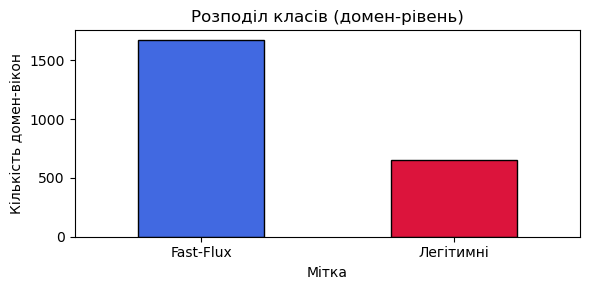

In [7]:
# домен отримує мітку на основі того, який хост до нього звертався
# для кожного рядка в df_raw визначаємо row_label за src_ip:
# якщо src_ip є у BOTNET_IPS, то row_label = 1.0  (fast-flux домен)
# якщо src_ip є у NORMAL_IPS, то row_label = 0.0  (легітимний домен)
# якщо src_ip невідомий, то row_label = NaN (домен буде видалено згодом)
# якщо до домену зверталися і botnet, і normal, то обирається максимальне значення max(1.0, 0.0) = 1.0

domain_labels = (
    df_raw
    .assign(
        row_label=lambda d: d['src_ip'].map(
            lambda ip: 1.0 if ip in BOTNET_IPS
                       else (0.0 if ip in NORMAL_IPS else np.nan)
        )
    )
    .groupby('query_name')['row_label']
    .max()  # якщо є хоча б один запит від BOTNET_IPS, то домен вважається fast-flux
    .reset_index()
    .rename(columns={'row_label': 'label'})
)

# доєднуємо мітки до агрегованого датафрейму за ключем query_name
df_agg = df_agg.merge(domain_labels, on='query_name', how='left')

# видаляємо домени без мітки
df_agg = df_agg.dropna(subset=['label'])

# виводимо статистику балансу класів
n1 = (df_agg['label'] == 1).sum()
n0 = (df_agg['label'] == 0).sum()
print(f'Fast-flux: {n1:,}  |  Легітимні: {n0:,}  |  Всього: {len(df_agg):,}')
print(f'Частка: {n1/(n1+n0)*100:.1f}% fast-flux')

# Стовпчикова діаграма розподілу класів
df_agg['label'].map({0.0:'Легітимні',1.0:'Fast-Flux'}).value_counts().plot(
    kind='bar', color=['royalblue','crimson'], edgecolor='black', figsize=(6,3))
plt.title('Розподіл класів (домен-рівень)')
plt.ylabel('Кількість домен-вікон')
plt.xlabel('Мітка')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

In [8]:
# перевірка форми датафрейму після розмітки
# рядки - домени з відомою міткою (2323 записи), стовпці - 26 ознак + 1 мітка
df_agg.shape

(2323, 27)

In [9]:
# детальна інформація про типи даних стовпців і кількість непорожніх значень
df_agg.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2323 entries, 2 to 12776
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   query_name          2323 non-null   object 
 1   n_unique_ips        2323 non-null   int64  
 2   ip_churn_rate       2323 non-null   float64
 3   n_queries           2323 non-null   int64  
 4   query_freq          2323 non-null   float64
 5   obs_hours           2323 non-null   float64
 6   ttl_mean            2214 non-null   float64
 7   ttl_std             2323 non-null   float64
 8   ttl_min             2214 non-null   float64
 9   ttl_max             2214 non-null   float64
 10  ttl_entropy         2323 non-null   float64
 11  low_ttl_frac        2323 non-null   float64
 12  n_unique_asns       2323 non-null   int64  
 13  n_unique_countries  2323 non-null   int64  
 14  n_unique_cnames     2323 non-null   int64  
 15  has_cname           2323 non-null   int64  
 16  frac_priva

In [10]:
# перевірка пропущених значень у кожному стовпці
# TTL-поля, що мають порожні значення, означають відсутність А-відповідей для домену
df_agg.isnull().sum()

query_name              0
n_unique_ips            0
ip_churn_rate           0
n_queries               0
query_freq              0
obs_hours               0
ttl_mean              109
ttl_std                 0
ttl_min               109
ttl_max               109
ttl_entropy             0
low_ttl_frac            0
n_unique_asns           0
n_unique_countries      0
n_unique_cnames         0
has_cname               0
frac_private_ips        0
n_src_ips               0
n_dst_ips               0
uses_tcp                0
nxdomain_rate           0
servfail_rate           0
qry_name_len            0
qry_depth               0
qry_entropy             0
frac_a_queries          0
label                   0
dtype: int64

In [11]:
# підрахунок статистики fast-flux
# обираємо рядки, де src_ip = 147.32.84.165 (зараженого пристрою), після чого розгортаємо a_list методом explode ()
# (кожна IP-адреса - окремий рядок)

df_ff_raw = df_raw[df_raw['src_ip'].isin(BOTNET_IPS)].copy()
df_ff_ips = df_ff_raw[['query_name','a_list']].explode('a_list').copy()
df_ff_ips = df_ff_ips[df_ff_ips['a_list'].notna() & (df_ff_ips['a_list'] != '')]
df_ff_ips.columns = ['query_name','ip']

# зіставляємо кожну IP-адресу з кодом країни та ASN
df_ff_ips['country'] = df_ff_ips['ip'].map(
    lambda ip: ip_asn.get(ip, {}).get('country', None))
df_ff_ips['asn'] = df_ff_ips['ip'].map(
    lambda ip: ip_asn.get(ip, {}).get('AS_number', None))

print(f'Fast-flux DNS-рядків: {len(df_ff_raw):,}')
print(f'IP-записів (A) total: {len(df_ff_ips):,}')
print(f'Унікальних IP: {df_ff_ips["ip"].nunique():,}')
print(f'Країн знайдено: {df_ff_ips["country"].notna().sum():,}')
print(f'ASN знайдено: {df_ff_ips["asn"].notna().sum():,}')

Fast-flux DNS-рядків: 7,552
IP-записів (A) total: 11,647
Унікальних IP: 1,745
Країн знайдено: 9,357
ASN знайдено: 11,481


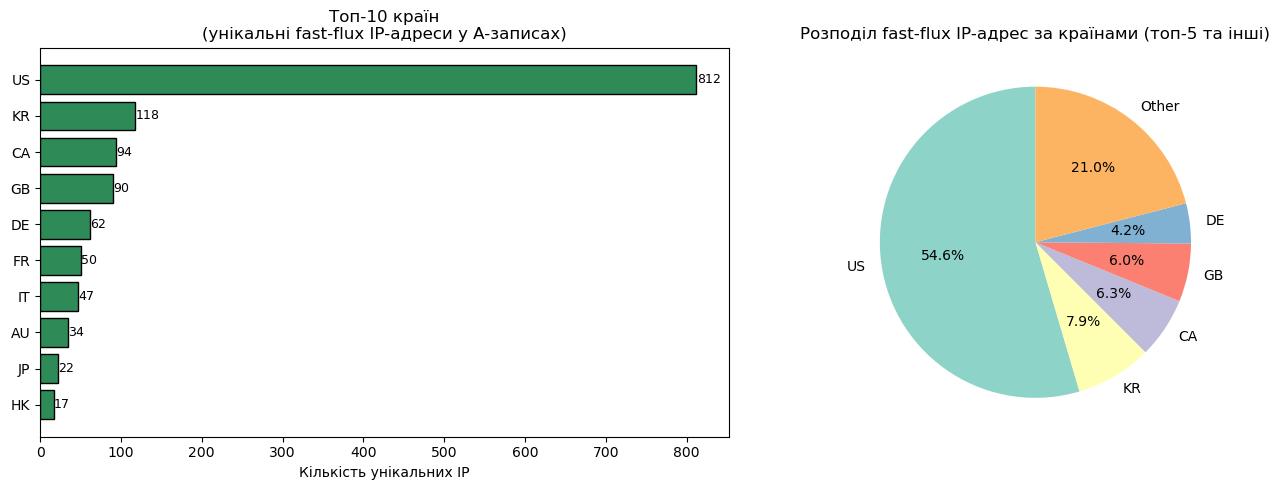

Топ-10 країн за унікальними fast-flux IP
   1. US  -   812 IP  (54.6%)
   2. KR  -   118 IP  (7.9%)
   3. CA  -    94 IP  (6.3%)
   4. GB  -    90 IP  (6.0%)
   5. DE  -    62 IP  (4.2%)
   6. FR  -    50 IP  (3.4%)
   7. IT  -    47 IP  (3.2%)
   8. AU  -    34 IP  (2.3%)
   9. JP  -    22 IP  (1.5%)
  10. HK  -    17 IP  (1.1%)

Всього унікальних IP з відомою країною: 1,488
Всього унікальних IP без країни: 257


In [12]:
# виведення топ-10 країн за кількістю унікальних IP-адрес у А-записах

uniq_ip_country = df_ff_ips.drop_duplicates(subset='ip')[['ip','country']].dropna()
top10 = uniq_ip_country['country'].value_counts().head(10)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# побудова горизонтальної гістограми
bars = axes[0].barh(top10.index[::-1], top10.values[::-1],
                    color='seagreen', edgecolor='black')
axes[0].set_xlabel('Кількість унікальних IP')
axes[0].set_title('Топ-10 країн\n(унікальні fast-flux IP-адреси у A-записах)')
for bar, val in zip(bars, top10.values[::-1]):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontsize=9)

# побудова кругової діаграми
total_ip_country = uniq_ip_country['country'].value_counts()
top5  = total_ip_country.head(5)
other = total_ip_country.iloc[5:].sum()
pie_data = pd.concat([top5, pd.Series({'Other': other})])
axes[1].pie(pie_data.values, labels=pie_data.index, autopct='%1.1f%%',
            startangle=90, colors=plt.cm.Set3.colors[:len(pie_data)])
axes[1].set_title('Розподіл fast-flux IP-адрес за країнами (топ-5 та інші)')

plt.tight_layout()
plt.show()

print('Топ-10 країн за унікальними fast-flux IP')
for rank, (country, count) in enumerate(top10.items(), 1):
    pct = count / len(uniq_ip_country) * 100
    print(f'  {rank:2d}. {country}  -  {count:4d} IP  ({pct:.1f}%)')
print(f'\nВсього унікальних IP з відомою країною: {len(uniq_ip_country):,}')
print(f'Всього унікальних IP без країни: '
      f'{(df_ff_ips.drop_duplicates("ip")["country"].isna().sum()):,}')

## 6. Фінальна обробка та збереження

In [13]:
# obs_hours залишаємо як ознаку (тривалість спостереження)
# видаляємо нечисловий стовпець query_name, адже модель працює лише з числовими ознаками
df_out = df_agg.drop(columns=['query_name'], errors='ignore')

# заповнюємо пропущені значення нулями
feature_cols = [c for c in df_out.columns if c != 'label']
df_out[feature_cols] = df_out[feature_cols].fillna(0)

print(f'Кількість ознак: {len(feature_cols)}')
print(f'Кількість значень NaN: {df_out.isnull().sum().sum()}')

# виведення статистичного розподілу усіх числових ознак
df_out.describe()

Кількість ознак: 25
Кількість значень NaN: 0


,n_unique_ips,ip_churn_rate,n_queries,query_freq,obs_hours,ttl_mean,ttl_std,ttl_min,ttl_max,ttl_entropy,...,n_src_ips,n_dst_ips,uses_tcp,nxdomain_rate,servfail_rate,qry_name_len,qry_depth,qry_entropy,frac_a_queries,label
count,2323.000000,2323.00000,2323.000000,2323.000000,2323.000000,2323.000000,2323.000000,2323.000000,2323.000000,2323.000000,...,2323.000000,2323.000000,2323.000000,2323.000000,2323.000000,2323.000000,2323.000000,2323.000000,2323.000000,2323.000000
mean,2.182953,48.65354,48.206199,67.996102,2.973864,22273.614794,3664.223922,18859.909169,29039.088248,0.831699,...,2.389152,1.112355,0.000430,0.038282,0.003366,17.528196,2.055962,3.351746,0.703861,0.719759
std,5.105909,79.18530,868.280617,79.361572,5.756678,55862.238946,16609.181161,53347.384147,67959.393310,1.464550,...,4.790360,0.456400,0.020748,0.191285,0.054102,6.929288,0.953873,0.392048,0.264859,0.449214
min,0.000000,0.00000,1.000000,0.174559,0.016667,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,0.000000,0.000000,0.000000,2.000000,0.000000,-0.000000,0.000000,0.000000
25%,1.000000,0.47572,1.000000,5.206326,0.016667,600.000000,0.000000,300.000000,600.000000,0.000000,...,1.000000,1.000000,0.000000,0.000000,0.000000,13.000000,1.000000,3.121928,0.500000,0.000000
50%,1.000000,60.00000,2.000000,60.000000,0.016667,3600.000000,0.000000,1800.000000,3600.000000,0.000000,...,1.000000,1.000000,0.000000,0.000000,0.000000,17.000000,2.000000,3.392747,0.526316,1.000000
75%,1.000000,60.00000,5.000000,120.000000,1.469189,14400.000000,398.922723,14400.000000,21600.000000,1.000000,...,1.000000,1.000000,0.000000,0.000000,0.000000,21.000000,2.000000,3.625000,1.000000,1.000000
max,78.000000,900.00000,37533.000000,2293.240475,16.370149,604800.000000,272949.737468,604800.000000,604800.000000,10.169767,...,77.000000,9.000000,1.000000,1.000000,1.000000,76.000000,6.000000,4.546305,1.000000,1.000000


In [14]:
# визначення стовпців, що підлягають нормалізації
# пропускаємо цільову змінну (мітку) та бінарні/частотні ознаки
SKIP = {'label'}
binary_pfx = ('has_', 'is_', 'uses_', 'frac_')  # префікси бінарних/частотних ознак
SKIP |= {c for c in df_out.columns if any(c.startswith(p) for p in binary_pfx)}

# для решти числових стовпців виконуємо Z-score нормалізацію за допомогою методу StandartScaler (μ = 0, σ = 1)
# Z-score необхідна для коректної роботи лінійної регресії (через чутливість до масштабу) та ізоляційного лісу (при розкиді значень)
scale_cols = [c for c in df_out.select_dtypes(include=[np.number]).columns
              if c not in SKIP]

scaler = StandardScaler()
df_out[scale_cols] = scaler.fit_transform(df_out[scale_cols])

# збереження датафрейму у форматі .csv
df_out.to_csv(OUTPUT_CSV, index=False)

# виведення часу виконання ноутбука
elapsed = time.perf_counter() - _notebook_start
print(f"Час виконання ноутбука: {elapsed:.2f} с  ({elapsed/60:.1f} хв)")

Час виконання ноутбука: 78.58 с  (1.3 хв)
